# Random Forest Regression

## Objective

The objective of this notebook is to build a Random Forest Regression model that predicts an employee's monthly salary.

In this notebook, you will learn how to:

- Load the dataset
- Handle missing values
- Define features and target variable
- Split the dataset into training and testing sets
- Train a Random Forest Regression model
- Make predictions
- Evaluate the model using regression metrics

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

**Step 1: Mount Google Drive**

Google Drive is mounted to access the dataset and save the trained model.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Load the Dataset**

Load the Employee Salary Classification dataset from Google Drive.

In [3]:
df = pd.read_excel(
    "/content/drive/MyDrive/Datasets/Salary_Logistic_Regression_Multiclass_Classification_Dataset.xlsx"
)

df

,Experience_Years,Education_Level,Age,Monthly_Salary_PKR,Salary_Category
0,1,12.0,22.0,40000,0
1,2,12.0,23.0,45000,0
2,2,14.0,24.0,50000,0
3,3,14.0,25.0,58000,0
4,3,NaN,26.0,65000,0
5,4,16.0,27.0,70000,0
6,4,16.0,28.0,74000,0
7,5,16.0,29.0,82000,1
8,5,18.0,30.0,90000,1
9,6,18.0,31.0,98000,1


**Step 3: Handle Missing Values**

Check whether the dataset contains missing values.

If any missing values are found, replace them with the median value of the respective column.

In [4]:
print("\nBefore Filling Missing Values")
print(df.isnull().sum())

df["Education_Level"] = df["Education_Level"].fillna(
    df["Education_Level"].median()
)

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

print("\nAfter Filling Missing Values")

print(df.isnull().sum())


Before Filling Missing Values
Experience_Years      0
Education_Level       2
Age                   1
Monthly_Salary_PKR    0
Salary_Category       0
dtype: int64

After Filling Missing Values
Experience_Years      0
Education_Level       0
Age                   0
Monthly_Salary_PKR    0
Salary_Category       0
dtype: int64


**Step 4: Define Features and Target Variable**

The independent variables are:

- Experience Years
- Education Level
- Age

The dependent variable is:

- Monthly Salary (PKR)

In [5]:
X = df[
    [
        "Experience_Years",
        "Education_Level",
        "Age"
    ]
]

y = df["Monthly_Salary_PKR"]

**Step 5: Split the Dataset**

Split the dataset into training and testing sets.

- 80% Training Data
- 20% Testing Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Step 6: Train the Random Forest Regression Model**

Train the Random Forest Regression model using the training dataset.

A Random Forest combines the predictions of multiple Decision Trees to improve prediction accuracy and reduce overfitting.

The **n_estimators** parameter specifies the number of Decision Trees in the Random Forest.

In [7]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)



RandomForestRegressor(random_state=42)

**Step 7: Make Predictions**

Predict the salary category using the testing dataset.

In [8]:
y_pred = model.predict(
    X_test
)

print(y_pred)

[127901.9047619  126005.23809524 278200.         101090.
 156440.         212680.         248000.         224330.
 304400.         177030.        ]


**Step 7: Make Predictions**

Predict the monthly salary using the testing dataset.

In [9]:
y_pred = model.predict(
    X_test
)

print(y_pred)

[127901.9047619  126005.23809524 278200.         101090.
 156440.         212680.         248000.         224330.
 304400.         177030.        ]


**Step 8: Evaluate Model Performance**

The model performance is evaluated using:

- **R² Score:** Measures how well the model explains the variation in the target variable.
- **MAE (Mean Absolute Error):** Measures the average absolute difference between the actual and predicted values.
- **MSE (Mean Squared Error):** Measures the average squared difference between the actual and predicted values.
- **RMSE (Root Mean Squared Error):** Measures the average prediction error in the same unit as the target variable.

In [10]:
r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

print("R² Score :", round(r2,4))

print("MAE :", round(mae,2))

print("MSE :", round(mse,2))

print("RMSE :", round(rmse,2))

R² Score : 0.9919
MAE : 4686.29
MSE : 34456069.3
RMSE : 5869.93


**Step 9: Predict the Monthly Salary for a New Employee**

Predict the monthly salary for an employee with:

- Experience = 10 Years
- Education Level = 18 Years
- Age = 35 Years

In [11]:

prediction = model.predict(
    [[10,18,35]]
)

print("Predicted Monthly Salary:")

print(
    round(prediction[0],2),
    "PKR"
)

Predicted Monthly Salary:
140801.07 PKR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


**Step 10: Display Feature Importance**

Feature Importance shows how much each feature contributes to predicting the monthly salary.

Features with higher importance have a greater influence on the model's predictions.

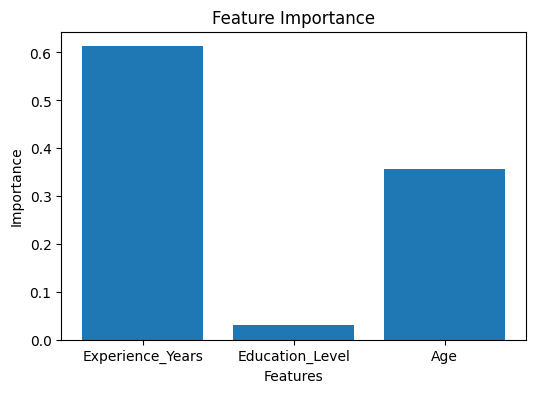

In [12]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(6,4))

plt.bar(
    X.columns,
    importance
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

**Conclusion**

In this notebook, a Random Forest Regression model was successfully developed to predict employees' monthly salaries. The dataset was preprocessed by handling missing values and splitting it into training and testing sets. The trained model was then used to predict salaries for new employees. Finally, the model's performance was evaluated using R² Score, MAE, MSE, and RMSE. The importance of each feature was also analyzed to understand its contribution to the model's predictions.